# End-to-End Training Pipeline
This notebook contains all steps for training the model: loading data, preprocessing, feature engineering, hyperparameter tuning, evaluation, and saving.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pickle

ModuleNotFoundError: No module named 'seaborn'

### 1. Load Data & Clean Logic

In [2]:
# Load dataset
df = pd.read_csv('cardio_train.csv', sep=';', index_col='id')
df.drop_duplicates(inplace=True)

# Fix logic error: Diastolic higher than Systolic
mask = df['ap_lo'] > df['ap_hi']
df.loc[mask, ['ap_hi', 'ap_lo']] = df.loc[mask, ['ap_lo', 'ap_hi']].values

### 2. Cap Outliers & Feature Engineering

In [3]:
# Cap extreme values (Outliers)
def cap_values(series, lower_limit, upper_limit):
    return series.clip(lower=lower_limit, upper=upper_limit)

df['age_years'] = (df['age'] / 365).astype(int)
df['height'] = cap_values(df['height'], 140, 200)
df['weight'] = cap_values(df['weight'], 40, 160)
df['ap_hi']  = cap_values(df['ap_hi'], 80, 200)
df['ap_lo']  = cap_values(df['ap_lo'], 50, 120)

# Feature Engineering: BMI
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)
df['BMI_cat'] = pd.cut(df['BMI'], 
                       bins=[0, 18.5, 25, 30, 100], 
                       labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Feature Engineering: BP Categories
def get_bp_category(row):
    if row['ap_hi'] < 120 and row['ap_lo'] < 80:
        return 'Normal'
    elif row['ap_hi'] >= 140 or row['ap_lo'] >= 90:
        return 'High'
    else:
        return 'Elevated'
df['BP_cat'] = df.apply(get_bp_category, axis=1)

# One-Hot Encoding
df_final = pd.get_dummies(df, columns=['cholesterol', 'gluc', 'BMI_cat', 'BP_cat'], drop_first=False)
df_final.drop(['age'], axis=1, inplace=True)

### 3. Data Splitting & Scaling

In [4]:
# Split into Train/Test
X = df_final.drop('cardio', axis=1)
y = df_final['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
numerical_cols = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'BMI']
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

### 4. Hyperparameter Tuning

In [5]:
# Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 10, 20],
    'subsample': [0.8, 0.9, 1.0]
}

gb_model = GradientBoostingClassifier(random_state=42)

random_search = RandomizedSearchCV(estimator=gb_model,
                                   param_distributions=param_dist,
                                   n_iter=20,
                                   cv=3,
                                   scoring='accuracy',
                                   n_jobs=-1,
                                   verbose=1,
                                   random_state=42)

random_search.fit(X_train, y_train)
print(f"\nBest Parameters Found: {random_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {random_search.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters Found: {'subsample': 0.9, 'n_estimators': 100, 'min_samples_split': 20, 'max_depth': 4, 'learning_rate': 0.05}
Best Cross-Validation Accuracy: 0.7358


### 5. Final Model Evaluation


Final Test Set Accuracy: 73.59%

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.78      0.75      6901
           1       0.77      0.69      0.73      7095

    accuracy                           0.74     13996
   macro avg       0.74      0.74      0.74     13996
weighted avg       0.74      0.74      0.74     13996



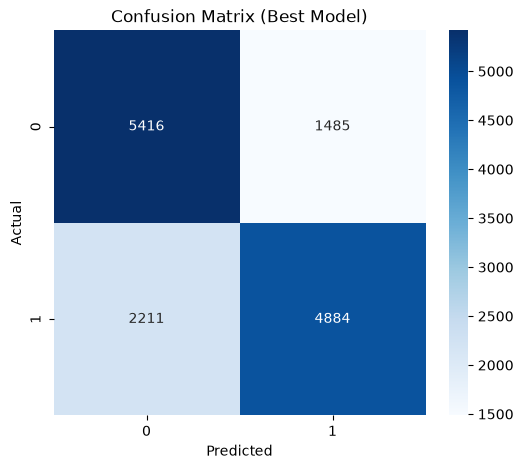

In [6]:
# Train final model with best params and evaluate
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\nFinal Test Set Accuracy: {acc:.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Plot
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Best Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 6. Save Artifacts

In [7]:
# Save Model and Preprocessing Artifacts
artifacts = {
    "model": best_model,
    "scaler": scaler,
    "features": X_train.columns.tolist(),
    "numerical_cols": numerical_cols
}

with open('cardio_model_final_retrained.pkl', 'wb') as file:
    pickle.dump(artifacts, file)

print("Model saved successfully!")

Model saved successfully!
